Cell 1: Google Drive Mount
python

from google.colab import drive
drive.mount('/content/drive')

Purpose: Mounts Google Drive to access data files stored in the cloud.
Why it's needed: The dataset file is too large to upload directly to Colab, so we use Google Drive as storage.
What happens: After running, you'll click an authorization link and get a mount point at /content/drive/ where your files appear.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Data Loading and Initial Inspection

Purpose: Loads the dataset and shows what the data looks like.
What it does:

Imports essential Python libraries for data science

Reads the CSV file from Google Drive

Shows the first 5 rows to understand the data structure
Output revealed: The data has 94,380 rows and 54 columns with vehicle sensor data, timestamps, and driver classes.

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/data.csv')


df.head()

,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,...,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,...,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,0,13.3,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


**Cell 3: Column Removal (Feature Selection)**

Purpose: Removes irrelevant or redundant columns from the dataset.
Why remove these:

PathOrder: Just a sequence number, not useful for analysis

Duplicate columns: Like Engine_coolant_temperature.1

Highly specific engine parameters not useful for driver identification

Constant or near-constant columns
Result: Reduces from 54 to 36 columns.

In [6]:
import pandas as pd
drop_cols = [
    'PathOrder',
    'Minimum_indicated_engine_torque',
    'Maximum_indicated_engine_torque',
    'Torque_scaling_factor(standardization)',
    'Standard_Torque_Ratio',
    'Requested_spark_retard_angle_from_TCU',
    'TCU_requests_engine_torque_limit_(ETL)',
    'TCU_requested_engine_RPM_increase',
    'Fuel_Pressure',
    'Inhibition_of_engine_fuel_cut_off',
    'Engine_in_fuel_cut_off',
    'Glow_plug_control_request',
    'Activation_of_Air_compressor',
    'Engine_Idel_Target_Speed',
    'Clutch_operation_acknowledge',
    'Converter_clutch',
    'Gear_Selection',
    'Engine_coolant_temperature.1'  # Dupe of original coolant
]

# Apply drop (safe: checks existence, no error if missing)
dfc = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Quick sanity: Print shapes and var check for further prunes
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {dfc.shape}")


Original shape: (94380, 54)
Cleaned shape: (94380, 36)


In [7]:
print(len(dfc.columns))
n_col = len(dfc.columns)

36


**Cell 5: Time Window Compression Function**

Purpose: Compresses multiple time-series rows into a single summary row.
How it works: Takes all rows in a time window (e.g., 10 seconds of data) and calculates the average for each sensor.
Example: If throttle readings are [5.2, 6.1, 5.2, 4.7] over 4 seconds, returns [5.3] as the average.
Why it's useful: Reduces data volume while preserving overall patterns.

In [8]:
import numpy as np
import math
def compress(matrix):
    np_matrix = np.array(matrix)
    ls = np_matrix.mean(axis=0).tolist()
    #return [ (1 - math.exp(-abs(v)) )**2 for v in ls]
    return  ls

cell 6
Purpose: The core data preprocessing function that cleans and organizes data.
What it does:

    Removes non-numeric columns (except 'Class')

    Removes low-variance columns using coefficient of variation threshold

    Groups data into time windows (e.g., every 10 seconds)

    Compresses each window using the compress() function

    Tracks which rows belong to which driver class
    Parameters:

    df_v: Input dataframe

    vr_th: Variance ratio threshold (0.1 = keep columns with CV > 10%)

    timing: Time window size in seconds



In [9]:
def clean(df_v, vr_th , timing = 5):
    cl_df = df_v.copy()
    cols_to_drop = []

    for col_n in cl_df.columns:
        col = cl_df[col_n]

        if col_n == "Class":
            continue

        if not pd.api.types.is_numeric_dtype(col):
            cols_to_drop.append(col_n)
            continue

        if col_n == "Time(s)":
            continue

        mean_val = col.mean()
        var_val = col.var()

        if pd.isna(var_val) or var_val == 0:
            cols_to_drop.append(col_n)
            continue

        std_val = np.sqrt(var_val)

        if abs(mean_val) > 1e-10:
            cv = std_val / abs(mean_val)

            if cv < vr_th:
                cols_to_drop.append(col_n)

    print(len(cols_to_drop))
    cl_df =  cl_df.drop(columns=cols_to_drop)
    matrix = []
    positions = {}
    ligne = []
    for index, row in cl_df.iterrows():
      t = row["Time(s)"]
      if t > 0 and t % timing == 0 :
        if row["Class"] in positions:
            positions[row["Class"]].append(len(matrix))
        else:
            positions[row["Class"]] = [len(matrix)]
        matrix.append(compress(ligne))
        ligne = []
      ligne.append([val for key, val in row.items() if key not in ['Time(s)', 'Class']])



    return cl_df , matrix ,  positions

In [10]:
dfv , matrix ,  positions = clean(dfc, 0.1 ,10)
print(len(matrix) , dfv.shape[0])


3
9420 94380


In [11]:
def drivermatrixes(matrix , positions):
  matrixes = []
  for driver in positions.keys():
    matrixes.append( [ [matrix[v] ]for v in positions[driver] ])
  return matrix



## Cell 9: Feature Engineering - Statistical Feature Extraction

**What this function does:** This is the most critical step in our analysis. It transforms raw vehicle sensor data into meaningful "driving signatures" that uniquely identify each driver.

**Think of it this way:** If raw sensor data is like watching a video of someone driving, this function extracts their "driving personality" from that video.

### Step 1: Making Data Comparable (Robust Scaling)
Instead of using traditional scaling that can be thrown off by extreme values (like a sudden hard brake), we use a more resilient method. We find the middle value (median) and the typical spread (IQR - middle 50% range) for each sensor, then adjust all values relative to these. This makes the data from different sensors and different drivers comparable on the same scale.

### Step 2: Weighting What Matters (Feature Importance)
Not all sensors are equally important for identifying drivers. A sensor that barely changes (like engine coolant temperature once warmed up) tells us less than one that varies a lot (like steering wheel angle). We automatically give more weight to sensors that show more variation across time, as these are likely more informative for distinguishing driving styles.

### Step 3: Extracting the "DNA" of Driving
For each 10-second driving window, we extract **6 key characteristics**:

**First 3 features (Current State):**
1. **Average Behavior** - What's the typical driving style in this window?
2. **Consistency** - How steady or variable is the driving?
3. **Asymmetry** - Does the driver tend to favor certain actions (like more acceleration than braking)?

**Next 3 features (Dynamic Changes):**
4. **Change Magnitude** - How much does driving behavior change from the previous window?
5. **Change Consistency** - Are changes smooth or abrupt?
6. **Change Direction** - Do changes tend to go more in one direction than another?

**Why these 6 features work:**  
The first three capture "what" the driver is doing (their static style), while the last three capture "how" they do it (their dynamic adjustments). Together, they form a complete fingerprint of driving behavior that's unique to each person, much like handwriting analysis.

**Output:** Each 10-second window of driving (with 36 different sensor readings) gets reduced to just 6 numbers. These 6 numbers contain the essence of the driving behavior in that window and are perfect for training machine learning models to recognize drivers.

In [12]:
import numpy as np
from scipy.stats import skew
def scale_vec(mat):
  mat = np.array(mat)
  n = len(mat[0])
  m = len(mat)
  scaled_mat = []
  variances = []
  weights = []
  def getrange(x):
    return [  mat[i][x] for i in range(m) ]
  for i in range(n):
    observations = getrange(i)
    median = np.median(observations)
    q1 = np.percentile(observations, 25)
    q3 = np.percentile(observations, 75)
    iqr = q3 - q1
    observations = (observations - median)/(0.001 +iqr)
    weights.append(1 / (np.var(observations) +  1e-10 ) )
    scaled_mat.append(list(observations))
  deltas = []
  sum_weights = sum(weights)
  weights= [ weights[i] /sum_weights  for i in range(n)]
  scaled = []
  for j in range(m - 1 ):
    observations = [ ( scaled_mat[i][j+1]-  scaled_mat[i][j]) * weights[i]  for i in range(n) ]
    obs = [ scaled_mat[i][j] * weights[i] for i in range(n)]
    scaled.append(obs)
    deltas.append(observations)

  #vectorize
  vecs = []
  def getInt(row):
    row = np.array(row)
    return np.mean(row), np.std(row) , skew(row)
  print(len(scaled_mat))
  for i in range(m-1):
    mx , stx , skx= getInt(scaled[i])
    my , sty , sky= getInt(deltas[i])
    vecs.append([ mx , stx , skx , my , sty , sky])
  return vecs






In [13]:
vecs = scale_vec(matrix)

31


In [14]:
def kmeans_sixDimensions(features, max_k=15, method='elbow'):
    import numpy as np
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import silhouette_score

    X = np.array(features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k_range = range(2, min(max_k + 1, len(X_scaled) - 1))

    inertias = []
    silhouettes = []
    models = []

    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X_scaled)
        labels = km.labels_

        inertias.append(km.inertia_)

        if len(set(labels)) > 1:
            silhouettes.append(silhouette_score(X_scaled, labels))
        else:
            silhouettes.append(np.nan)

        models.append(km)

    if method == 'elbow':
        diff1 = np.diff(inertias)
        diff2 = np.diff(diff1)
        if len(diff2) > 0:
            elbow_idx = np.argmax(np.abs(diff2)) + 2
            optimal_k = k_range[elbow_idx] if elbow_idx < len(k_range) else k_range[-1]
        else:
            optimal_k = k_range[np.argmax(np.abs(diff1))]
    else:  # silhouette
        valid_idx = ~np.isnan(silhouettes)
        if np.any(valid_idx):
            optimal_k = k_range[np.nanargmax(silhouettes)]
        else:
            optimal_k = k_range[len(k_range)//2]

    best_model = models[optimal_k - 2]
    labels = best_model.labels_

    cluster_counts = {}
    for label in np.unique(labels):
        cluster_counts[int(label)] = int(np.sum(labels == label))

    return {
        'labels': labels,
        'optimal_k': int(optimal_k),
        'cluster_counts': cluster_counts,
        'total_samples': len(labels),
        'main_clusters': len(cluster_counts)
    }

In [29]:
kmeans_result = kmeans_sixDimensions(vecs)
kmeans_labels = kmeans_result['labels']
print(f"K-means found {kmeans_result['optimal_k']} clusters")
print(f"Cluster distribution: {kmeans_result['cluster_counts']}")

K-means found 4 clusters
Cluster distribution: {0: 1252, 1: 3070, 2: 3172, 3: 1925}


In [16]:
def visualize_all_2d_combinations(feature_vectors, cluster_labels=None,
                                  feature_names=None, sample_size=500,
                                  random_state=42, figsize=(20, 15)):
    """
    Visualize all possible 2D combinations of the 6-dimensional feature space.

    Parameters:
    -----------
    feature_vectors : array-like, shape (n_samples, 6)
        The 6-dimensional feature vectors
    cluster_labels : array-like, shape (n_samples,), optional
        Cluster labels (KMeans, DBSCAN, or driver IDs)
    feature_names : list of str, optional
        Feature names (default provided)
    sample_size : int, optional
        Number of points to sample
    random_state : int, optional
        Random seed
    figsize : tuple, optional
        Figure size

    Returns:
    --------
    fig, axes
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from itertools import combinations
    from scipy import stats
    import warnings
    warnings.filterwarnings('ignore')

    X = np.array(feature_vectors)
    n_features = X.shape[1]

    if len(X) > sample_size:
        np.random.seed(random_state)
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sampled = X[indices]
        labels_sampled = np.array(cluster_labels)[indices] if cluster_labels is not None else None
    else:
        X_sampled = X
        labels_sampled = cluster_labels

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    combos = list(combinations(range(n_features), 2))

    fig, axes = plt.subplots(3, 5, figsize=figsize)
    axes = axes.flatten()

    if labels_sampled is not None:
        unique_labels = np.unique(labels_sampled)
        n_clusters = len(unique_labels)
        colors = cm.tab20c(np.linspace(0, 1, n_clusters))
        if -1 in unique_labels:
            noise_idx = np.where(unique_labels == -1)[0][0]
            colors[noise_idx] = [0.5, 0.5, 0.5, 1.0]
    else:
        colors = ['steelblue']
        unique_labels = None

    for idx, (i, j) in enumerate(combos):
        ax = axes[idx]
        x = X_sampled[:, i]
        y = X_sampled[:, j]

        corr, p_value = stats.pearsonr(x, y) if len(x) > 2 else (0, 1)

        if labels_sampled is not None:
            for c_idx, label in enumerate(unique_labels):
                mask = labels_sampled == label
                color = colors[c_idx]
                lab = None
                if idx == 0:
                    lab = 'Noise' if label == -1 else f'Cluster {label}'

                if label == -1:
                    ax.scatter(x[mask], y[mask], c=[color], s=20, alpha=0.3,
                               marker='x', label=lab)
                else:
                    ax.scatter(x[mask], y[mask], c=[color], s=30, alpha=0.6,
                               label=lab)
        else:
            ax.scatter(x, y, c=colors[0], s=30, alpha=0.6)

        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel(feature_names[j], fontsize=9)

        sig_star = "*" if p_value < 0.05 else ""
        title_color = 'red' if abs(corr) > 0.5 else ('orange' if abs(corr) > 0.3 else 'black')
        ax.set_title(f'r = {corr:.2f}{sig_star}', fontsize=10, color=title_color, pad=5)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    for idx in range(len(combos), len(axes)):
        axes[idx].axis('off')

    fig.suptitle('2D Feature Space Analysis - All 15 Pairwise Combinations\n' +
                 ('Color-coded by Driver Clusters' if cluster_labels is not None else 'All Driving Patterns'),
                 fontsize=14, fontweight='bold', y=1.02)

    if unique_labels is not None and len(unique_labels) <= 10:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    return fig, axes


def analyze_feature_correlations(feature_vectors, feature_names=None,
                                 cluster_labels=None, threshold=0.5):
    """
    Analyze and visualize correlation matrix of all 6 features.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    X = np.array(feature_vectors)

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    df = pd.DataFrame(X, columns=feature_names)

    if cluster_labels is not None:
        df['Cluster'] = cluster_labels
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)

        fig, axes = plt.subplots(1, n_clusters + 1, figsize=(5*(n_clusters + 1), 4))

        corr_matrix = df.drop(columns=['Cluster']).corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, ax=axes[0],
                    cbar_kws={"shrink": 0.8})
        axes[0].set_title('Overall Correlation')

        for idx, cluster in enumerate(unique_clusters):
            name = 'Noise' if cluster == -1 else f'Cluster {cluster}'
            cluster_data = df[df['Cluster'] == cluster].drop(columns=['Cluster'])

            if len(cluster_data) > 2:
                cluster_corr = cluster_data.corr()
                sns.heatmap(cluster_corr, annot=True, cmap='coolwarm', center=0,
                            square=True, linewidths=0.5, ax=axes[idx + 1],
                            cbar_kws={"shrink": 0.8})
                axes[idx + 1].set_title(f'{name}\n(n={len(cluster_data)})')
            else:
                axes[idx + 1].text(0.5, 0.5, 'Insufficient\nData',
                                  ha='center', va='center')
                axes[idx + 1].set_title(f'{name}\n(n={len(cluster_data)})')
                axes[idx + 1].set_xticks([])
                axes[idx + 1].set_yticks([])

        plt.suptitle('Feature Correlation Analysis by Cluster', fontsize=14, fontweight='bold')
    else:
        corr_matrix = df.corr()
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, ax=ax,
                    cbar_kws={"shrink": 0.8})
        ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix)):
                if abs(corr_matrix.iloc[i, j]) > threshold and i != j:
                    ax.text(j + 0.5, i + 0.5, '★',
                            ha='center', va='center', fontsize=14,
                            color='gold', fontweight='bold')

    plt.tight_layout()
    return corr_matrix


def identify_separating_features(feature_vectors, cluster_labels,
                                 feature_names=None, top_n=3):
    """
    Identify feature combinations that best separate clusters.
    """

    import numpy as np
    from itertools import combinations
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import cross_val_score
    import matplotlib.pyplot as plt

    X = np.array(feature_vectors)
    y = np.array(cluster_labels)

    mask = y != -1
    X_clean = X[mask] if np.any(mask) else X
    y_clean = y[mask] if np.any(mask) else y

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    combos = list(combinations(range(X.shape[1]), 2))
    separation_scores = []

    for i, j in combos:
        X_subset = X_clean[:, [i, j]]
        if len(np.unique(y_clean)) > 1 and len(X_subset) > len(np.unique(y_clean)):
            try:
                lda = LinearDiscriminantAnalysis()
                scores = cross_val_score(lda, X_subset, y_clean, cv=min(5, len(np.unique(y_clean))))
                separation_scores.append(np.mean(scores))
            except:
                separation_scores.append(0)
        else:
            separation_scores.append(0)

    sorted_idx = np.argsort(separation_scores)[::-1]
    best_combinations = []
    best_scores = []

    print("=" * 70)
    print("TOP FEATURE COMBINATIONS FOR CLUSTER SEPARATION")
    print("=" * 70)
    print("\nRank | Features (X vs Y)       | Separation Score | Interpretation")
    print("-" * 70)

    for rank, idx in enumerate(sorted_idx[:top_n]):
        i, j = combos[idx]
        score = separation_scores[idx]
        best_combinations.append((i, j))
        best_scores.append(score)

        interp = ("Excellent" if score > 0.8 else
                  "Good" if score > 0.6 else
                  "Moderate" if score > 0.4 else
                  "Poor")

        print(f"{rank+1:^4} | {feature_names[i]:>10} vs {feature_names[j]:<10} | {score:^16.3f} | {interp}")

    print("-" * 70)

    fig, axes = plt.subplots(1, min(top_n, 3), figsize=(4*min(top_n, 3), 4))
    if top_n == 1:
        axes = [axes]

    unique_labels = np.unique(y)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for ax_idx, combo_idx in enumerate(sorted_idx[:top_n]):
        i, j = combos[combo_idx]
        score = separation_scores[combo_idx]
        ax = axes[ax_idx]

        for l_idx, label in enumerate(unique_labels):
            mask = y == label
            color = colors[l_idx]
            if label == -1:
                ax.scatter(X[mask, i], X[mask, j], c=[color], s=20, alpha=0.3,
                           marker='x', label='Noise')
            else:
                ax.scatter(X[mask, i], X[mask, j], c=[color], s=30, alpha=0.6,
                           label=f'Cluster {label}')

        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(feature_names[j])
        ax.set_title(f'Rank {ax_idx+1}: Score = {score:.3f}', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(f'Top {min(top_n, 3)} Feature Combinations for Driver Separation',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()

    return best_combinations, best_scores



(<Figure size 2000x1500 with 15 Axes>,
 array([<Axes: title={'center': 'r = 0.17*'}, xlabel='Mean_State', ylabel='Std_State'>,
        <Axes: title={'center': 'r = -0.16*'}, xlabel='Mean_State', ylabel='Skew_State'>,
        <Axes: title={'center': 'r = -0.32*'}, xlabel='Mean_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = 0.28*'}, xlabel='Mean_State', ylabel='Std_Change'>,
        <Axes: title={'center': 'r = -0.05'}, xlabel='Mean_State', ylabel='Skew_Change'>,
        <Axes: title={'center': 'r = 0.42*'}, xlabel='Std_State', ylabel='Skew_State'>,
        <Axes: title={'center': 'r = -0.02'}, xlabel='Std_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = 0.09*'}, xlabel='Std_State', ylabel='Std_Change'>,
        <Axes: title={'center': 'r = -0.09*'}, xlabel='Std_State', ylabel='Skew_Change'>,
        <Axes: title={'center': 'r = -0.01'}, xlabel='Skew_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = -0.04'}, xlabel='Skew_State', y

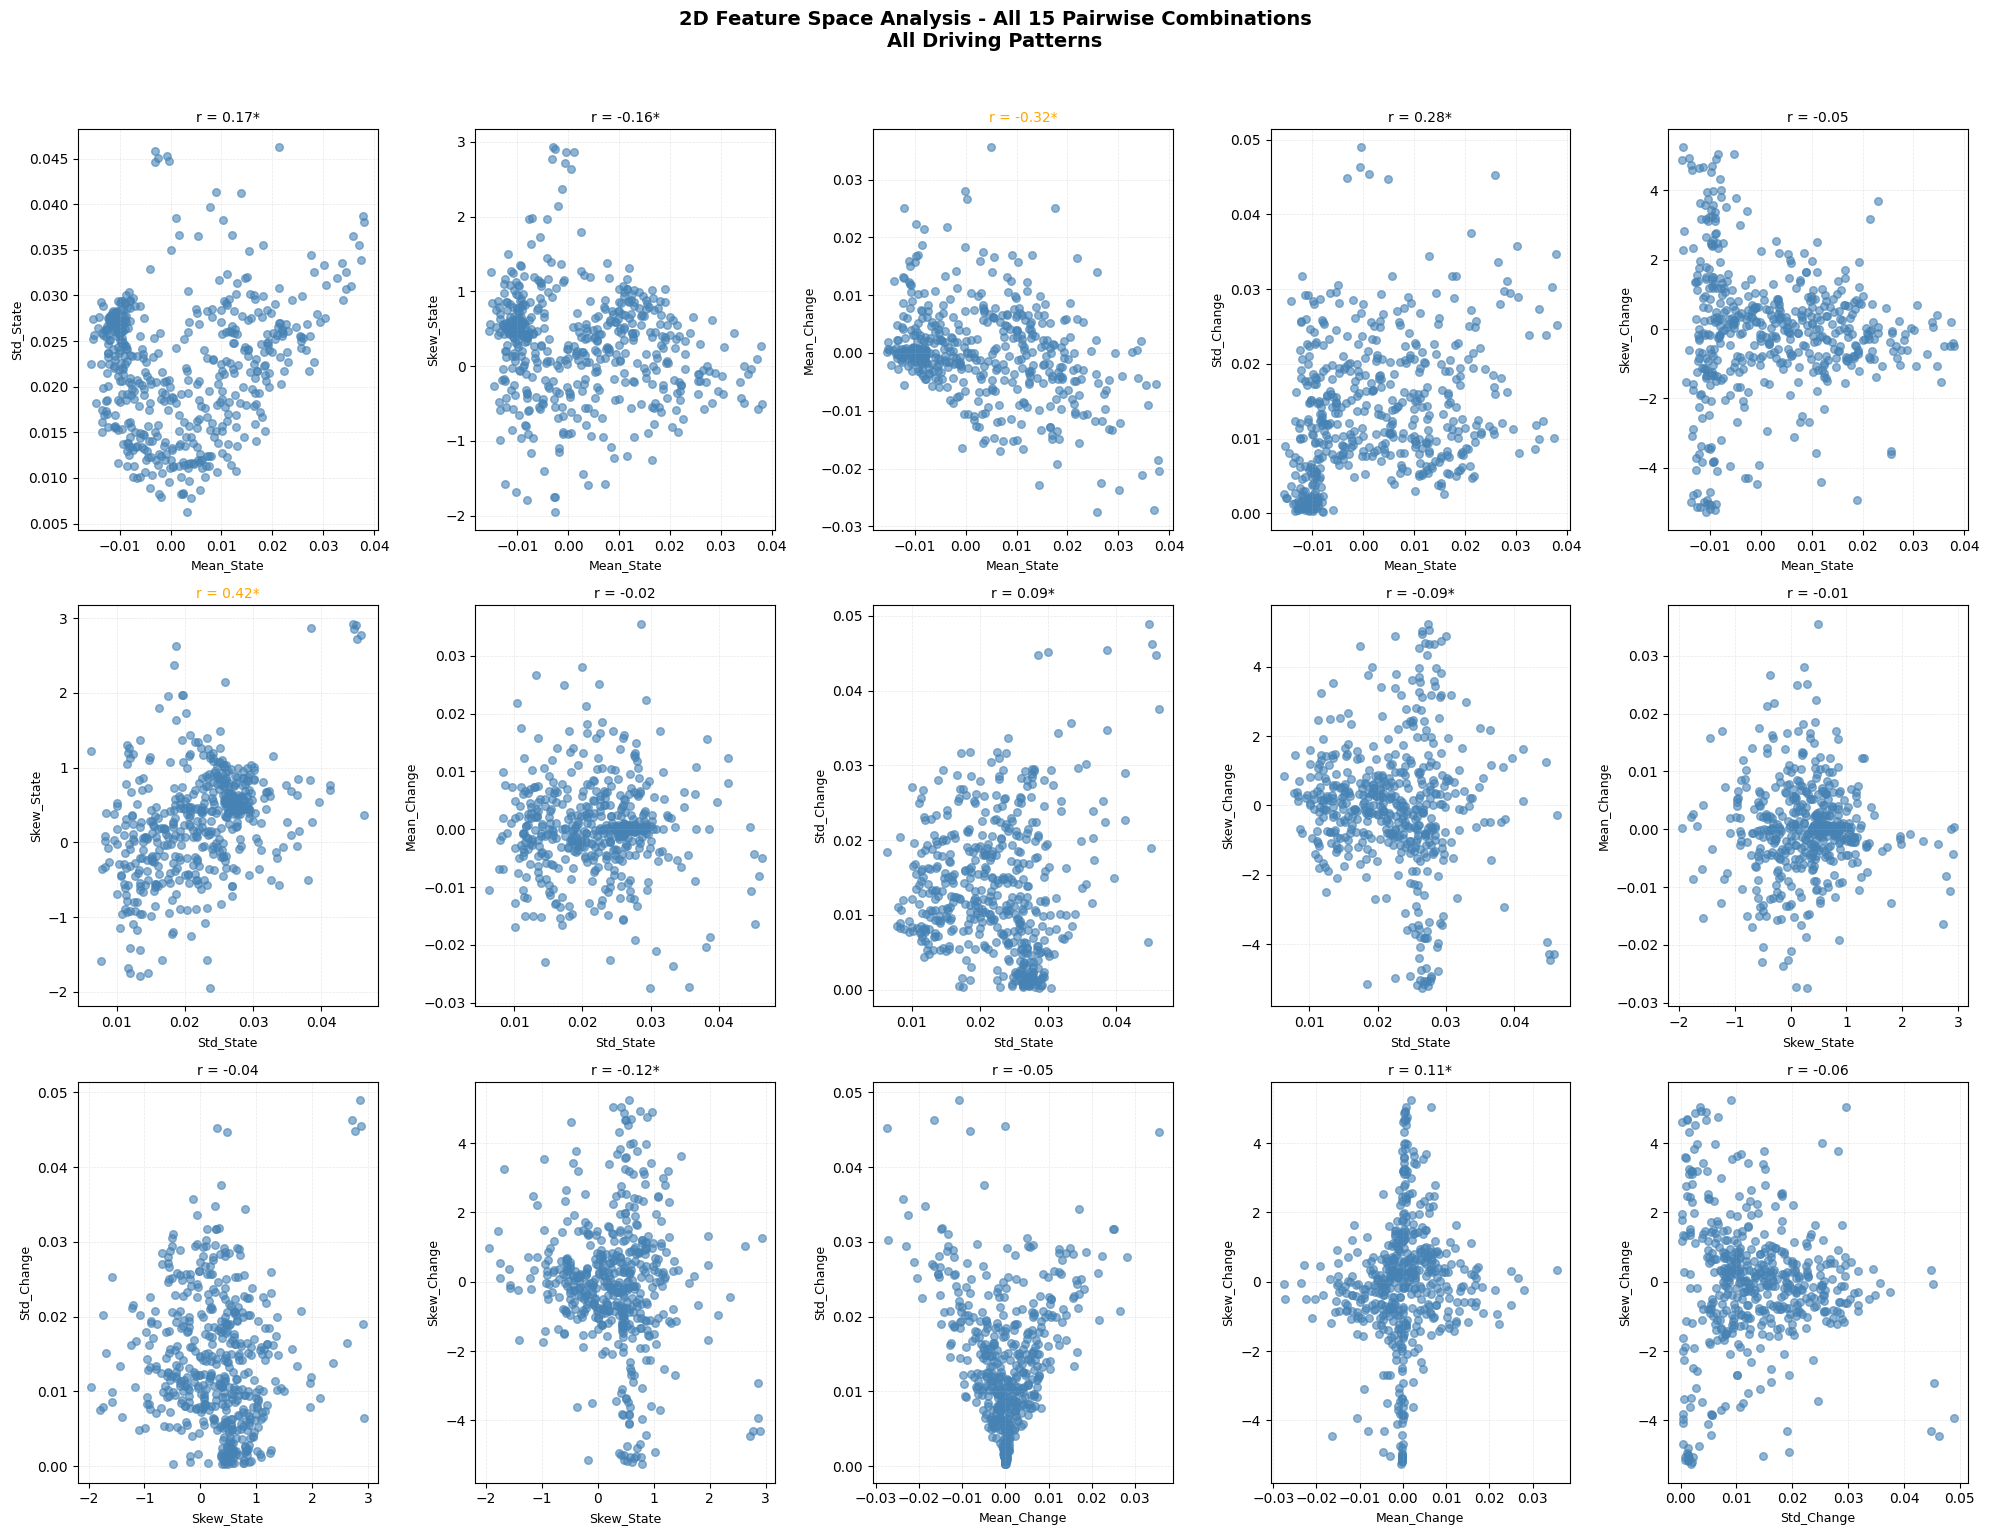

In [17]:
visualize_all_2d_combinations(vecs)



---

# Part 2: DBSCAN Clustering Analysis

## Introduction to DBSCAN

After analyzing driver behavior using K-means clustering, we now apply **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to the same feature space. Unlike K-means, which assumes spherical clusters and requires specifying the number of clusters beforehand, DBSCAN:

1. **Automatically discovers the number of clusters** based on data density
2. **Identifies outliers** as noise points that don't belong to any cluster
3. **Handles arbitrary cluster shapes** - not limited to spherical clusters
4. **Is robust to outliers** - doesn't force every point into a cluster

### Why DBSCAN for Driver Behavior?

DBSCAN is particularly suitable for driver behavior assessment because:
- **Outlier Detection**: Reckless driving events may appear as isolated outliers rather than forming distinct clusters
- **Natural Groupings**: Safe driving patterns may form dense regions, while aggressive driving creates sparser patterns
- **No Assumptions**: Unlike K-means, we don't need to assume how many driving styles exist

### Key DBSCAN Parameters

1. **eps (ε)**: The maximum distance between two points to be considered neighbors
2. **min_samples**: The minimum number of points required to form a dense region (cluster)

A point is classified as:
- **Core point**: Has at least `min_samples` points within `eps` distance
- **Border point**: Within `eps` of a core point but has fewer than `min_samples` neighbors
- **Noise point**: Neither core nor border (labeled as -1)

In [18]:
# Import DBSCAN and supporting libraries
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import pandas as pd

print("Libraries imported successfully!")
print(f"Feature vector shape: {np.array(vecs).shape}")
print(f"Number of 6D feature vectors: {len(vecs)}")

Libraries imported successfully!
Feature vector shape: (9419, 6)
Number of 6D feature vectors: 9419


## DBSCAN Parameter Optimization

Finding optimal DBSCAN parameters is crucial for meaningful clustering. We'll use two methods:

### Method 1: K-Distance Graph (for eps)
The k-distance graph plots the distance to the k-th nearest neighbor for each point. The "elbow" in this plot suggests a good `eps` value.

### Method 2: Grid Search (for both parameters)
We'll test different combinations of `eps` and `min_samples` and evaluate them using:
- **Silhouette Score**: Measures how similar points are to their own cluster vs. other clusters (higher is better, range: -1 to 1)
- **Number of clusters**: Too many or too few clusters may indicate poor parameters
- **Noise percentage**: Excessive noise (>30%) may indicate eps is too small



Scaled feature matrix shape: (9419, 6)
Feature means: [ 1.44971388e-15 -1.67539479e-14  5.64623668e-16 -1.17163360e-17
  5.02897201e-15  3.81900690e-18]
Feature stds: [1. 1. 1. 1. 1. 1.]

Calculating 12-nearest neighbors for eps estimation...


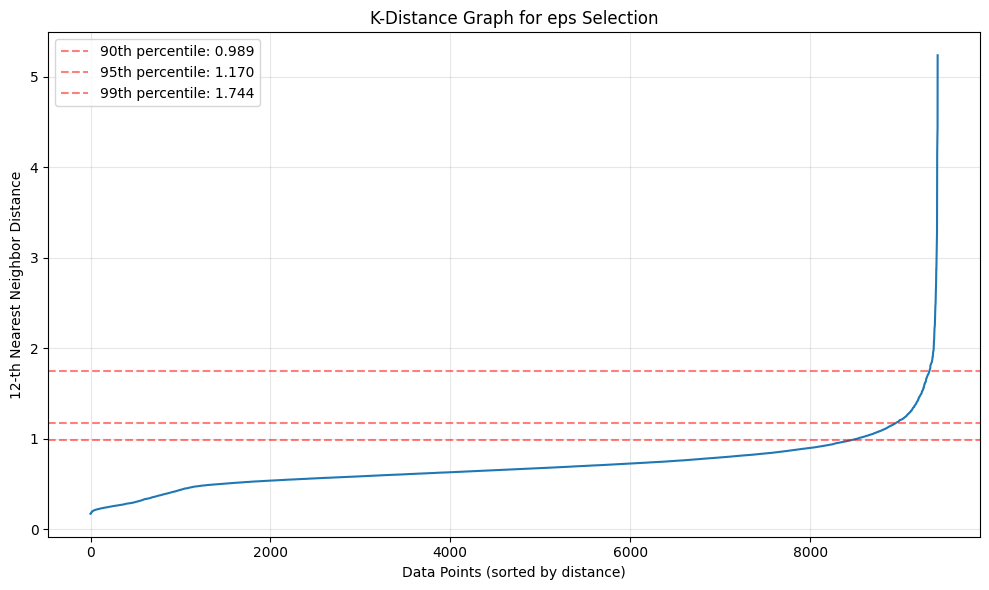


Suggested eps values to try:
  Conservative (90th percentile): 0.989
  Moderate (95th percentile): 1.170
  Liberal (99th percentile): 1.744


In [19]:
# Standardize features
X = np.array(vecs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Feature means: {X_scaled.mean(axis=0)}")
print(f"Feature stds: {X_scaled.std(axis=0)}")

# K-Distance Graph to find optimal eps
# We use k = min_samples (typically 2*dimensions for DBSCAN)
k = 2 * X_scaled.shape[1]  # 2*6 = 12

print(f"\nCalculating {k}-nearest neighbors for eps estimation...")

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.xlabel('Data Points (sorted by distance)')
plt.title('K-Distance Graph for eps Selection')
plt.grid(True, alpha=0.3)

# reference lines at common percentiles
percentiles = [90, 95, 99]
for p in percentiles:
    val = np.percentile(distances, p)
    plt.axhline(y=val, color='r', linestyle='--', alpha=0.5,
                label=f'{p}th percentile: {val:.3f}')

plt.legend()
plt.tight_layout()
plt.show()

# eps values based on the elbow
suggested_eps = [
    np.percentile(distances, 90),
    np.percentile(distances, 95),
    np.percentile(distances, 99)
]

print(f"\nSuggested eps values to try:")
print(f"  Conservative (90th percentile): {suggested_eps[0]:.3f}")
print(f"  Moderate (95th percentile): {suggested_eps[1]:.3f}")
print(f"  Liberal (99th percentile): {suggested_eps[2]:.3f}")

## Grid Search for Optimal Parameters

We'll now systematically test combinations of `eps` and `min_samples` to find the best parameters.

### Evaluation Metrics:
1. **Number of clusters**: Should be reasonable (2-10 for driving behavior)
2. **Noise percentage**: Should be moderate (5-20%)
3. **Silhouette score**: Measures cluster quality (higher is better)
4. **Cluster sizes**: Should have meaningful distribution



Testing 20 eps values: 0.800 to 2.000
Testing 6 min_samples values: [5, 10, 15, 20, 25, 30]
Total combinations to test: 120

Running grid search...
  Completed 5/20 eps values...
  Completed 10/20 eps values...
  Completed 15/20 eps values...
  Completed 20/20 eps values...

TOP 10 PARAMETER COMBINATIONS
     eps  min_samples  n_clusters  noise_pct  silhouette  n_noise
1.431579           20           2   1.305871    0.523481      123
1.242105           15           2   1.836713    0.523262      173
1.494737           20           2   1.082918    0.515021      102
1.305263           15           2   1.433273    0.508416      135
1.368421           15           2   1.274021    0.506722      120
1.178947           10           3   1.507591    0.389541      142
1.242105           10           3   1.104151    0.384446      104
1.178947            5           3   1.008600    0.382327       95
1.052632            5           3   1.624376    0.378499      153
1.115789           10           3 

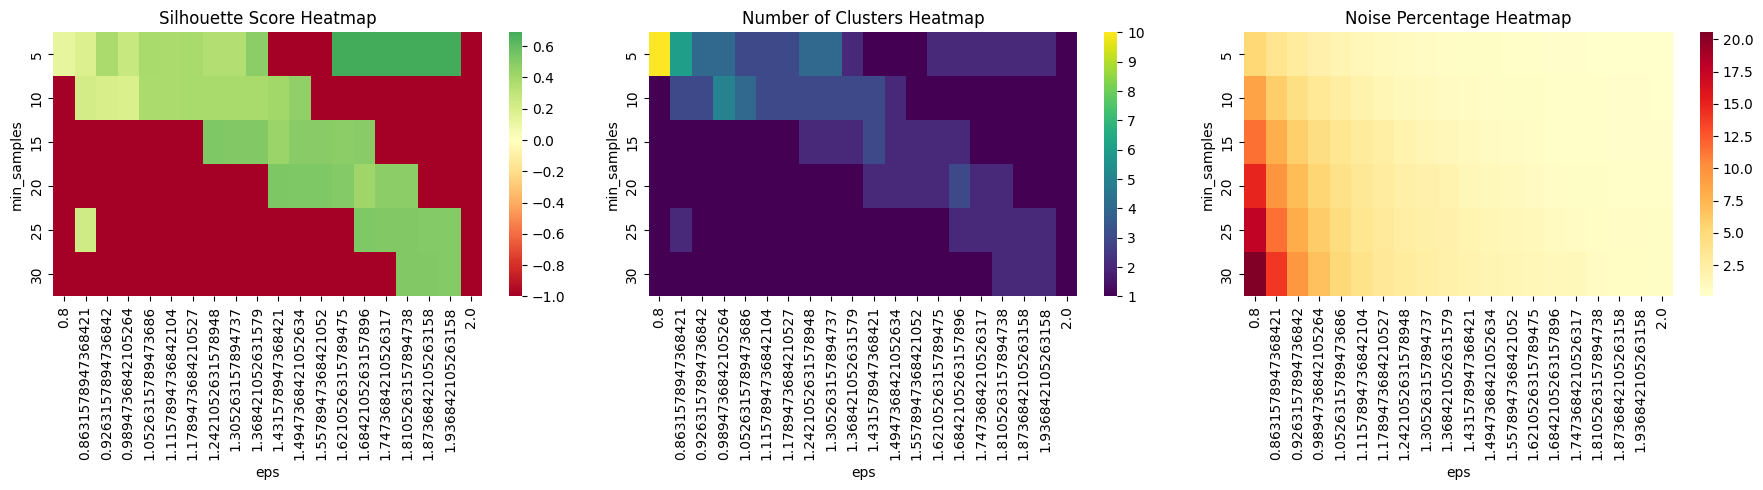

In [20]:
# Define parameter ranges to test

eps_values = np.linspace(0.8, 2.0, 20)  # based on k-distance plot
min_samples_values = [5, 10, 15, 20, 25, 30]

print(f"Testing {len(eps_values)} eps values: {eps_values.min():.3f} to {eps_values.max():.3f}")
print(f"Testing {len(min_samples_values)} min_samples values: {min_samples_values}")
print(f"Total combinations to test: {len(eps_values) * len(min_samples_values)}")

# Store results
results = []

print("\nRunning grid search...")
for i, eps in enumerate(eps_values):
    for min_samp in min_samples_values:
        # Run DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_scaled)

        # Calculate metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = 100 * n_noise / len(labels)

        # Silhouette score (only if we have 2+ clusters and not all noise)
        if n_clusters >= 2 and n_noise < len(labels) - 1:
            # Remove noise points for silhouette calculation
            mask = labels != -1
            if mask.sum() > 1:
                sil_score = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil_score = -1
        else:
            sil_score = -1

        results.append({
            'eps': eps,
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'noise_pct': noise_pct,
            'silhouette': sil_score,
            'n_noise': n_noise
        })

    # Progress indicator
    if (i + 1) % 5 == 0:
        print(f"  Completed {i + 1}/{len(eps_values)} eps values...")

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results)

# Filter to reasonable results
good_results = results_df[
    (results_df['n_clusters'] >= 2) &
    (results_df['n_clusters'] <= 15) &
    (results_df['noise_pct'] >= 1) &
    (results_df['noise_pct'] <= 30)
].copy()

if len(good_results) > 0:
    # Sort by silhouette score
    good_results = good_results.sort_values('silhouette', ascending=False)

    print("\n" + "="*80)
    print("TOP 10 PARAMETER COMBINATIONS")
    print("="*80)
    print(good_results.head(10).to_string(index=False))

    # Visualize parameter space
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Heatmap: Silhouette Score
    pivot_sil = results_df.pivot(index='min_samples', columns='eps', values='silhouette')
    sns.heatmap(pivot_sil, annot=False, cmap='RdYlGn', ax=axes[0], center=0)
    axes[0].set_title('Silhouette Score Heatmap')
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('min_samples')

    # Heatmap: Number of Clusters
    pivot_clusters = results_df.pivot(index='min_samples', columns='eps', values='n_clusters')
    sns.heatmap(pivot_clusters, annot=False, cmap='viridis', ax=axes[1])
    axes[1].set_title('Number of Clusters Heatmap')
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('min_samples')

    # Heatmap: Noise Percentage
    pivot_noise = results_df.pivot(index='min_samples', columns='eps', values='noise_pct')
    sns.heatmap(pivot_noise, annot=False, cmap='YlOrRd', ax=axes[2])
    axes[2].set_title('Noise Percentage Heatmap')
    axes[2].set_xlabel('eps')
    axes[2].set_ylabel('min_samples')

    plt.tight_layout()
    plt.show()

else:
    print("\n No good parameter combinations found!")
    print("\nAll results:")
    print(results_df.to_string(index=False))

## Selected DBSCAN Parameters

Based on the grid search results above, we now apply DBSCAN with the chosen parameters.


In [21]:

CHOSEN_EPS = 1.494737
CHOSEN_MIN_SAMPLES = 20

print(f"Applying DBSCAN with:")
print(f"  eps = {CHOSEN_EPS}")
print(f"  min_samples = {CHOSEN_MIN_SAMPLES}")

# Apply DBSCAN
dbscan = DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Analyze results
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)
noise_pct_dbscan = 100 * n_noise_dbscan / len(dbscan_labels)

print(f"\n{'='*60}")
print(f"DBSCAN CLUSTERING RESULTS")
print(f"{'='*60}")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan} ({noise_pct_dbscan:.1f}%)")
print(f"Number of clustered points: {len(dbscan_labels) - n_noise_dbscan}")

# Cluster size distribution
if n_clusters_dbscan > 0:
    print(f"\nCluster size distribution:")
    for cluster_id in range(n_clusters_dbscan):
        cluster_size = list(dbscan_labels).count(cluster_id)
        cluster_pct = 100 * cluster_size / len(dbscan_labels)
        print(f"  Cluster {cluster_id}: {cluster_size} points ({cluster_pct:.1f}%)")

    # Calculate silhouette score (excluding noise)
    mask = dbscan_labels != -1
    if mask.sum() > 1 and n_clusters_dbscan >= 2:
        sil_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        db_score = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        print(f"\nCluster Quality Metrics:")
        print(f"  Silhouette Score: {sil_dbscan:.4f} (higher is better, range: -1 to 1)")
        print(f"  Davies-Bouldin Score: {db_score:.4f} (lower is better)")

# Store labels for visualization
dbscan_labels_array = np.array(dbscan_labels)

Applying DBSCAN with:
  eps = 1.494737
  min_samples = 20

DBSCAN CLUSTERING RESULTS
Number of clusters: 2
Number of noise points: 102 (1.1%)
Number of clustered points: 9317

Cluster size distribution:
  Cluster 0: 9291 points (98.6%)
  Cluster 1: 26 points (0.3%)

Cluster Quality Metrics:
  Silhouette Score: 0.5150 (higher is better, range: -1 to 1)
  Davies-Bouldin Score: 0.5305 (lower is better)


## DBSCAN Cluster Interpretation

Now we'll analyze what each cluster represents in terms of driving behavior by examining the 6-dimensional feature statistics for each cluster.

Recall our 6 features:
1. **Mean State**: Average driving behavior
2. **Std State**: Consistency of driving
3. **Skew State**: Asymmetry (bias toward acceleration/braking)
4. **Mean Change**: Magnitude of behavioral changes
5. **Std Change**: Consistency of changes
6. **Skew Change**: Directional bias in changes

In [22]:
# Create DataFrame with features and cluster labels
feature_names = ['Mean State', 'Std State', 'Skew State',
                 'Mean Change', 'Std Change', 'Skew Change']

df_dbscan = pd.DataFrame(X_scaled, columns=feature_names)
df_dbscan['Cluster'] = dbscan_labels

# Calculate statistics for each cluster
print("="*100)
print("CLUSTER STATISTICS (Standardized Features)")
print("="*100)

cluster_stats = []

# Include noise as a separate category
unique_clusters = sorted(set(dbscan_labels))

for cluster_id in unique_clusters:
    cluster_data = df_dbscan[df_dbscan['Cluster'] == cluster_id]

    if cluster_id == -1:
        cluster_name = "NOISE/OUTLIERS"
    else:
        cluster_name = f"Cluster {cluster_id}"

    print(f"\n{cluster_name} (n={len(cluster_data)}):")
    print("-" * 100)

    stats_dict = {'Cluster': cluster_name, 'Size': len(cluster_data)}

    for feature in feature_names:
        mean_val = cluster_data[feature].mean()
        std_val = cluster_data[feature].std()
        stats_dict[f'{feature}_mean'] = mean_val
        stats_dict[f'{feature}_std'] = std_val
        print(f"  {feature:15s}: mean={mean_val:7.3f}, std={std_val:6.3f}")

    cluster_stats.append(stats_dict)

# Create summary table
cluster_summary = pd.DataFrame(cluster_stats)

print("\n" + "="*100)
print("CLUSTER INTERPRETATION GUIDE")
print("="*100)
print("High Mean State: Aggressive driving (high throttle, high RPM)")
print("High Std State: Inconsistent driving (variable behavior)")
print("Positive Skew State: Bias toward acceleration")
print("Negative Skew State: Bias toward braking")
print("High Mean Change: Frequent behavioral shifts")
print("High Std Change: Erratic/unpredictable changes")
print("Positive Skew Change: Tendency to increase intensity")
print("Negative Skew Change: Tendency to decrease intensity")

CLUSTER STATISTICS (Standardized Features)

NOISE/OUTLIERS (n=102):
----------------------------------------------------------------------------------------------------
  Mean State     : mean=  0.988, std= 2.192
  Std State      : mean=  2.756, std= 1.799
  Skew State     : mean=  1.410, std= 2.033
  Mean Change    : mean= -0.219, std= 2.355
  Std Change     : mean=  1.645, std= 2.006
  Skew Change    : mean= -0.243, std= 1.636

Cluster 0 (n=9291):
----------------------------------------------------------------------------------------------------
  Mean State     : mean= -0.010, std= 0.975
  Std State      : mean= -0.038, std= 0.933
  Skew State     : mean= -0.025, std= 0.954
  Mean Change    : mean=  0.005, std= 0.975
  Std Change     : mean= -0.027, std= 0.954
  Skew Change    : mean=  0.010, std= 0.983

Cluster 1 (n=26):
----------------------------------------------------------------------------------------------------
  Mean State     : mean= -0.414, std= 0.238
  Std State      



---

## 2D Visualization of DBSCAN Clusters

We now visualize all 15 possible 2D projections of our 6-dimensional feature space. This allows us to:

1. **Understand cluster separation**: Which feature pairs best distinguish clusters?
2. **Identify outliers**: Where do noise points appear in different projections?
3. **Validate clustering**: Do the clusters make intuitive sense?

### The 15 Possible Feature Combinations:

From our 6 features, we can create $\binom{6}{2} = 15$ unique 2D plots.




Creating 15 2D visualizations...


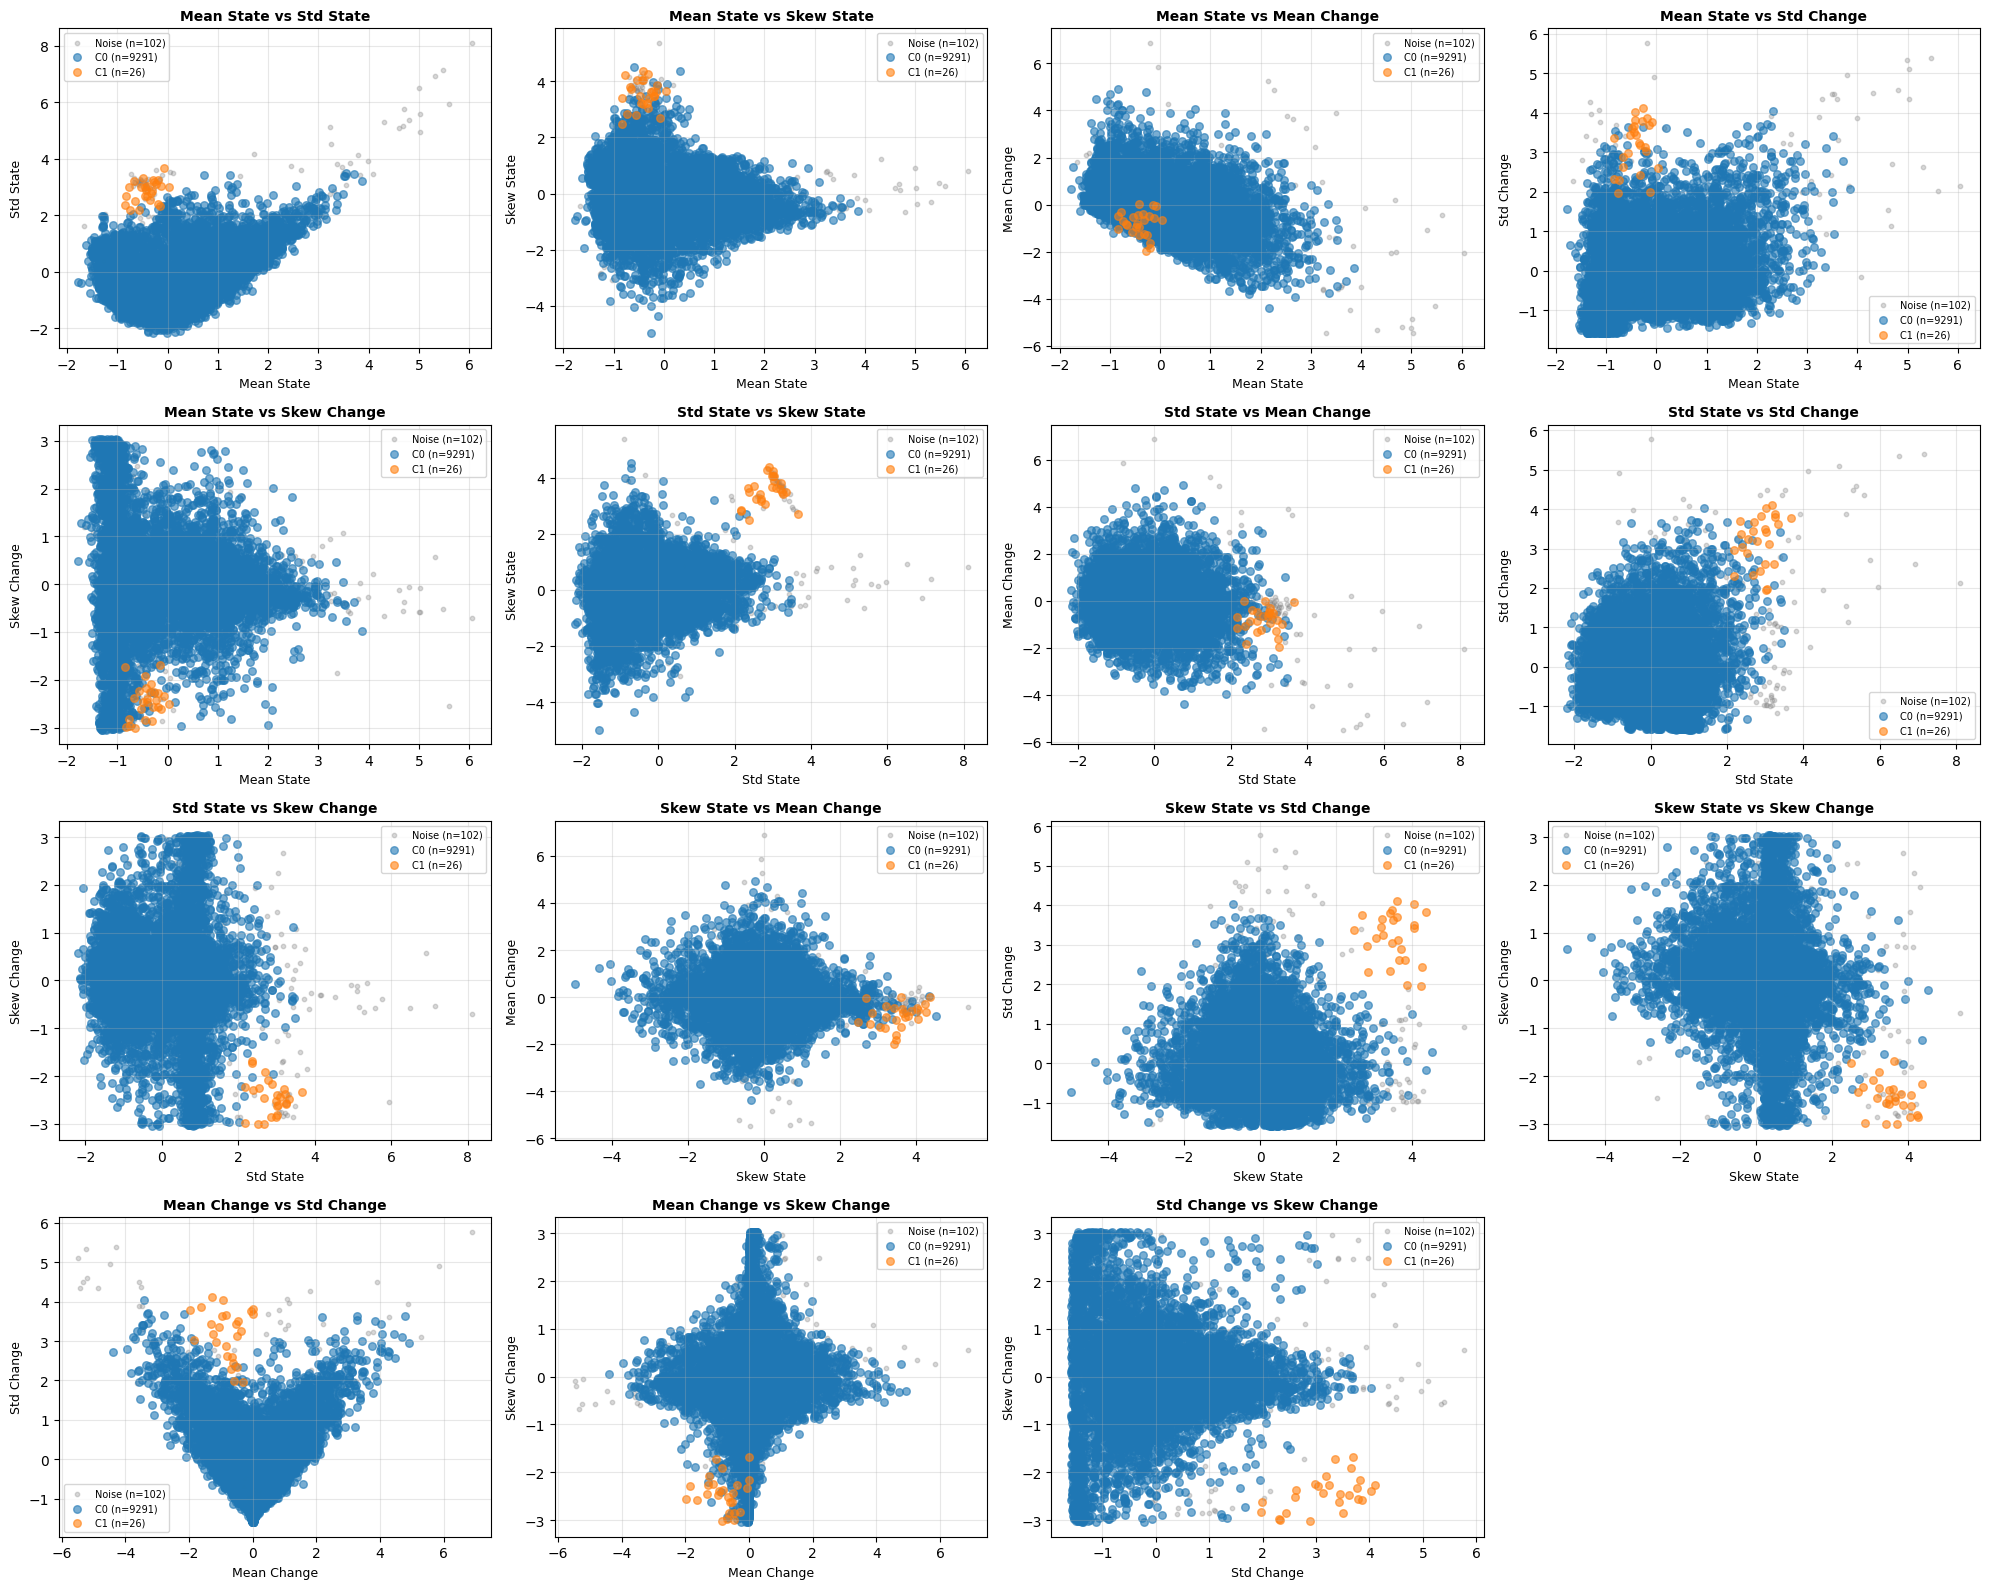


✓ All 15 visualizations created!
  Saved as: dbscan_all_15_combinations.png


In [23]:
# Generate all 15 2D combinations
feature_pairs = list(combinations(range(6), 2))
feature_names_short = ['Mean State', 'Std State', 'Skew State',
                       'Mean Change', 'Std Change', 'Skew Change']

print(f"Creating {len(feature_pairs)} 2D visualizations...")

# Create a large figure with all 15 subplots
fig = plt.figure(figsize=(20, 16))

# Color mapping: noise is grey, clusters are colored
unique_labels = sorted(set(dbscan_labels))
n_clusters_plot = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Create color map
colors = plt.cm.tab10(np.linspace(0, 1, 10))
color_dict = {}
for i, label in enumerate(unique_labels):
    if label == -1:
        color_dict[label] = 'grey'
    else:
        color_dict[label] = colors[label % 10]

# Plot each combination
for idx, (feat_i, feat_j) in enumerate(feature_pairs, 1):
    ax = fig.add_subplot(4, 4, idx)

    # Plot each cluster separately
    for cluster_id in unique_labels:
        mask = dbscan_labels_array == cluster_id

        if cluster_id == -1:
            # Plot noise points with smaller size and transparency
            ax.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                      c=color_dict[cluster_id], alpha=0.3, s=10,
                      label=f'Noise (n={mask.sum()})')
        else:
            # Plot cluster points
            ax.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                      c=[color_dict[cluster_id]], alpha=0.6, s=30,
                      label=f'C{cluster_id} (n={mask.sum()})')

    ax.set_xlabel(feature_names_short[feat_i], fontsize=9)
    ax.set_ylabel(feature_names_short[feat_j], fontsize=9)
    ax.set_title(f'{feature_names_short[feat_i]} vs {feature_names_short[feat_j]}',
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig('dbscan_all_15_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n All 15 visualizations created!")
print("  Saved as: dbscan_all_15_combinations.png")

## Identifying the Best 2D Projections

Not all feature pairs are equally informative. We'll now quantify which 2D projections best separate the clusters using:

1. **Silhouette Score per projection**: How well-separated are clusters in this 2D space?
2. **Inter-cluster distance**: How far apart are cluster centers?
3. **Intra-cluster compactness**: How tight are points within each cluster?

This helps us identify the "best" views of our high-dimensional data.

In [24]:
from sklearn.metrics import silhouette_score

# Evaluate each 2D projection
projection_scores = []

print("Evaluating all 15 feature pair combinations...\n")

for feat_i, feat_j in feature_pairs:
    # Extract 2D projection
    X_2d = X_scaled[:, [feat_i, feat_j]]

    # Calculate metrics only for non-noise points
    mask = dbscan_labels_array != -1

    if mask.sum() > 1 and n_clusters_dbscan >= 2:
        sil_2d = silhouette_score(X_2d[mask], dbscan_labels_array[mask])
    else:
        sil_2d = -1

    # Calculate mean inter-cluster distance
    cluster_centers = []
    for cluster_id in range(n_clusters_dbscan):
        cluster_mask = dbscan_labels_array == cluster_id
        if cluster_mask.sum() > 0:
            center = X_2d[cluster_mask].mean(axis=0)
            cluster_centers.append(center)

    if len(cluster_centers) >= 2:
        # Calculate pairwise distances between centers
        from scipy.spatial.distance import pdist
        inter_cluster_dist = pdist(cluster_centers).mean()
    else:
        inter_cluster_dist = 0

    projection_scores.append({
        'Feature 1': feature_names_short[feat_i],
        'Feature 2': feature_names_short[feat_j],
        'Silhouette': sil_2d,
        'Inter-cluster Distance': inter_cluster_dist,
        'Feat_Idx': (feat_i, feat_j)
    })

# Create DataFrame and sort
projections_df = pd.DataFrame(projection_scores)
projections_df = projections_df.sort_values('Silhouette', ascending=False)

print("="*90)
print("RANKING OF 2D PROJECTIONS BY CLUSTER SEPARATION QUALITY")
print("="*90)
print("\nTop 10 Best Feature Pairs:")
print(projections_df.head(10).to_string(index=False))

print("\n\nBottom 5 Worst Feature Pairs:")
print(projections_df.tail(5).to_string(index=False))

# Visualize the top 5 projections in detail
print("\n\nCreating detailed visualizations of top 5 projections...")

Evaluating all 15 feature pair combinations...

RANKING OF 2D PROJECTIONS BY CLUSTER SEPARATION QUALITY

Top 10 Best Feature Pairs:
  Feature 1   Feature 2  Silhouette  Inter-cluster Distance Feat_Idx
 Skew State  Std Change    0.646268                4.787727   (2, 4)
  Std State  Skew State    0.632778                4.579783   (1, 2)
 Skew State Skew Change    0.602186                4.316061   (2, 5)
  Std State  Std Change    0.595564                4.320668   (1, 4)
 Std Change Skew Change    0.586764                4.040067   (4, 5)
 Skew State Mean Change    0.542444                3.645068   (2, 3)
  Std State Skew Change    0.542357                3.791336   (1, 5)
 Mean State  Skew State    0.512756                3.574542   (0, 2)
Mean Change  Std Change    0.508387                3.313650   (3, 4)
 Mean State  Std Change    0.465181                3.235910   (0, 4)


Bottom 5 Worst Feature Pairs:
  Feature 1   Feature 2  Silhouette  Inter-cluster Distance Feat_Idx
  Std St

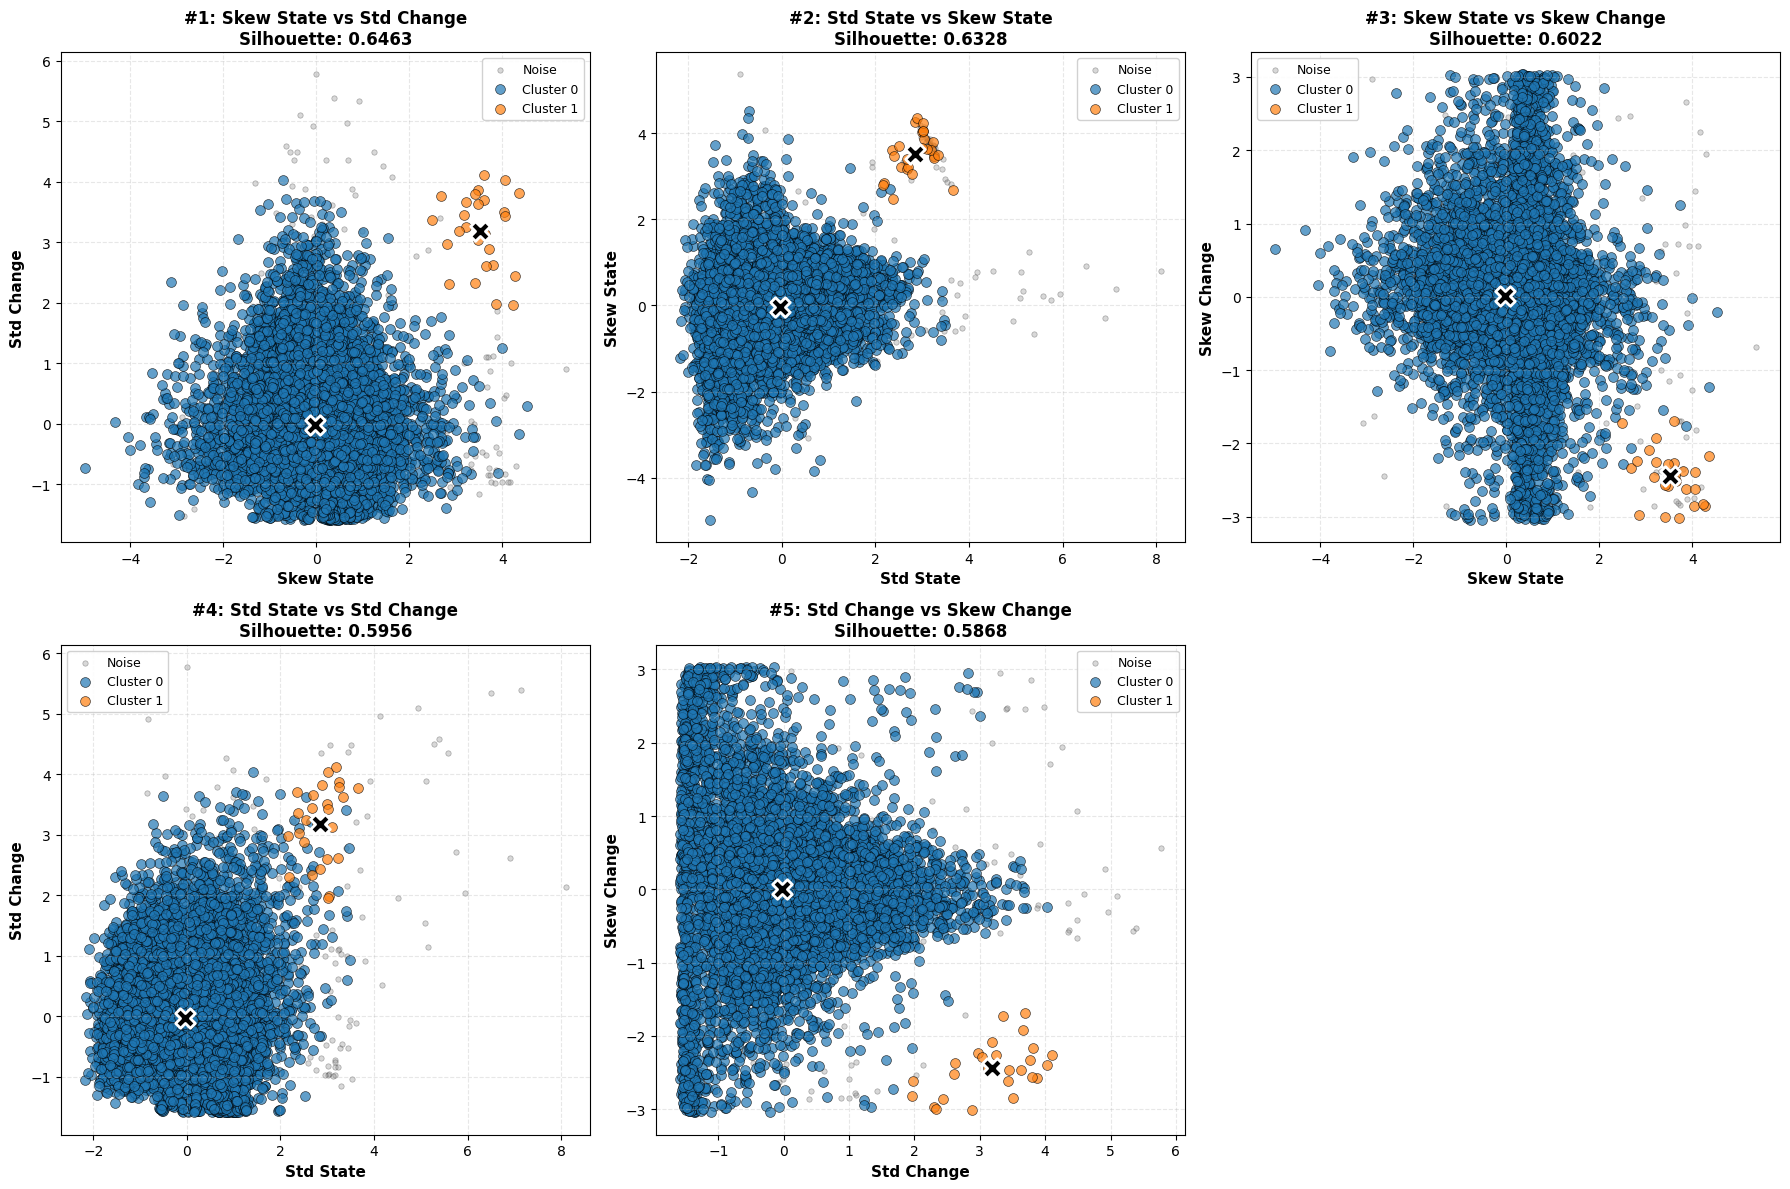


 Top 5 projections visualized
  Saved as: dbscan_top5_projections.png


In [26]:
# Get top 5 projections
top_5 = projections_df.head(5)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, row in enumerate(top_5.itertuples()):
    ax = axes[idx]
    feat_i, feat_j = row.Feat_Idx

    # Plot each cluster
    for cluster_id in unique_labels:
        mask = dbscan_labels_array == cluster_id

        if cluster_id == -1:
            ax.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                      c='grey', alpha=0.3, s=15, label=f'Noise',
                      edgecolors='k', linewidths=0.5)
        else:
            ax.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                      c=[color_dict[cluster_id]], alpha=0.7, s=50,
                      label=f'Cluster {cluster_id}',
                      edgecolors='k', linewidths=0.5)

            # Add cluster center
            center_i = X_scaled[mask, feat_i].mean()
            center_j = X_scaled[mask, feat_j].mean()
            ax.scatter(center_i, center_j, c='black', marker='X',
                      s=200, edgecolors='white', linewidths=2, zorder=10)

    ax.set_xlabel(row._1, fontsize=11, fontweight='bold')
    ax.set_ylabel(row._2, fontsize=11, fontweight='bold')
    ax.set_title(f'#{idx+1}: {row._1} vs {row._2}\n'
                 f'Silhouette: {row.Silhouette:.4f}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)

# Remove extra subplot
if len(top_5) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('dbscan_top5_projections.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 projections visualized")
print("  Saved as: dbscan_top5_projections.png")

## Temporal Analysis: Consecutive 5-Minute Driving Segments

To understand how driving behavior evolves over time, we'll analyze consecutive 5-minute segments. This helps us:

1. **Track behavior consistency**: Does a driver maintain their style?
2. **Identify transitions**: When does driving behavior change?
3. **Validate clustering**: Are consecutive windows clustered similarly?

### Analysis Approach:
- Select random 5-minute segments (30 consecutive 10-second windows)
- Calculate average silhouette score for each segment
- Visualize the temporal sequence of cluster assignments

**Note**: Each 10-second window has a silhouette score measuring how well it fits its assigned cluster.

In [30]:

def analyze_segment(start_idx, segment_length=30, labels=None, X_data=None):
    """
    Analyze a consecutive segment of driving windows

    Parameters:
    - start_idx: Starting index of the segment
    - segment_length: Number of consecutive windows (30 = 5 minutes of 10s windows)
    - labels: Cluster labels array
    - X_data: Scaled feature data
    """
    end_idx = start_idx + segment_length

    if end_idx > len(labels):
        return None

    # Extract segment
    segment_labels = labels[start_idx:end_idx]
    segment_data = X_data[start_idx:end_idx]

    # Calculate silhouette scores for non-noise points
    silhouette_scores = []

    for i, (label, point) in enumerate(zip(segment_labels, segment_data)):
        if label != -1:
            # Find all points in the same cluster (excluding this point)
            same_cluster_mask = (labels == label)
            same_cluster_data = X_data[same_cluster_mask]

            # Calculate average distance to same cluster
            if len(same_cluster_data) > 1:
                a = np.mean([np.linalg.norm(point - other)
                            for other in same_cluster_data])

                # Calculate average distance to nearest other cluster
                other_cluster_dists = []
                for other_label in set(labels):
                    if other_label != label and other_label != -1:
                        other_cluster_mask = (labels == other_label)
                        other_cluster_data = X_data[other_cluster_mask]
                        if len(other_cluster_data) > 0:
                            b_cluster = np.mean([np.linalg.norm(point - other)
                                                for other in other_cluster_data])
                            other_cluster_dists.append(b_cluster)

                if other_cluster_dists:
                    b = min(other_cluster_dists)
                    sil = (b - a) / max(a, b)
                else:
                    sil = 0
            else:
                sil = 0
        else:
            sil = -1  # Noise points

        silhouette_scores.append(sil)

    return {
        'start_idx': start_idx,
        'end_idx': end_idx,
        'labels': segment_labels,
        'silhouettes': silhouette_scores,
        'avg_silhouette': np.mean([s for s in silhouette_scores if s != -1]) if any(s != -1 for s in silhouette_scores) else -1,
        'cluster_distribution': {label: list(segment_labels).count(label)
                                for label in set(segment_labels)},
        'noise_count': list(segment_labels).count(-1),
        'dominant_cluster': max(set(segment_labels), key=list(segment_labels).count) if len(set(segment_labels)) > 0 else -1
    }

# Select random 5-minute segments
np.random.seed(42)
n_samples = 5  # Number of random segments to analyze (example)
max_start = len(dbscan_labels_array) - 30

if max_start > 0:
    random_starts = np.random.choice(max_start, size=min(n_samples, max_start), replace=False)

    segments_analysis = []

    print("="*100)
    print("ANALYZING RANDOM 5-MINUTE DRIVING SEGMENTS")
    print("="*100)
    print(f"\nEach segment = 30 consecutive 10-second windows (5 minutes)\n")

    for i, start in enumerate(random_starts):
        result = analyze_segment(start, segment_length=30,
                                labels=dbscan_labels_array,
                                X_data=X_scaled)

        if result:
            segments_analysis.append(result)

            print(f"\nSegment #{i+1}: Windows {result['start_idx']} to {result['end_idx']}")
            print(f"  Time: {result['start_idx']*10}s to {result['end_idx']*10}s")
            print(f"  Dominant Cluster: {result['dominant_cluster']}")
            print(f"  Average Silhouette: {result['avg_silhouette']:.4f}")
            print(f"  Noise Windows: {result['noise_count']}/30")
            print(f"  Cluster Distribution: {result['cluster_distribution']}")

    print("\n" + "="*100)
else:
    print("⚠️ Dataset too small for 5-minute segment analysis")
    segments_analysis = []

ANALYZING RANDOM 5-MINUTE DRIVING SEGMENTS

Each segment = 30 consecutive 10-second windows (5 minutes)


Segment #1: Windows 2273 to 2303
  Time: 22730s to 23030s
  Dominant Cluster: 0
  Average Silhouette: 0.4645
  Noise Windows: 0/30
  Cluster Distribution: {np.int64(0): 30}

Segment #2: Windows 3781 to 3811
  Time: 37810s to 38110s
  Dominant Cluster: 0
  Average Silhouette: 0.5745
  Noise Windows: 0/30
  Cluster Distribution: {np.int64(0): 30}

Segment #3: Windows 3045 to 3075
  Time: 30450s to 30750s
  Dominant Cluster: 0
  Average Silhouette: 0.5605
  Noise Windows: 0/30
  Cluster Distribution: {np.int64(0): 30}

Segment #4: Windows 6958 to 6988
  Time: 69580s to 69880s
  Dominant Cluster: 0
  Average Silhouette: 0.5224
  Noise Windows: 0/30
  Cluster Distribution: {np.int64(0): 30}

Segment #5: Windows 6831 to 6861
  Time: 68310s to 68610s
  Dominant Cluster: 0
  Average Silhouette: 0.4992
  Noise Windows: 0/30
  Cluster Distribution: {np.int64(0): 30}



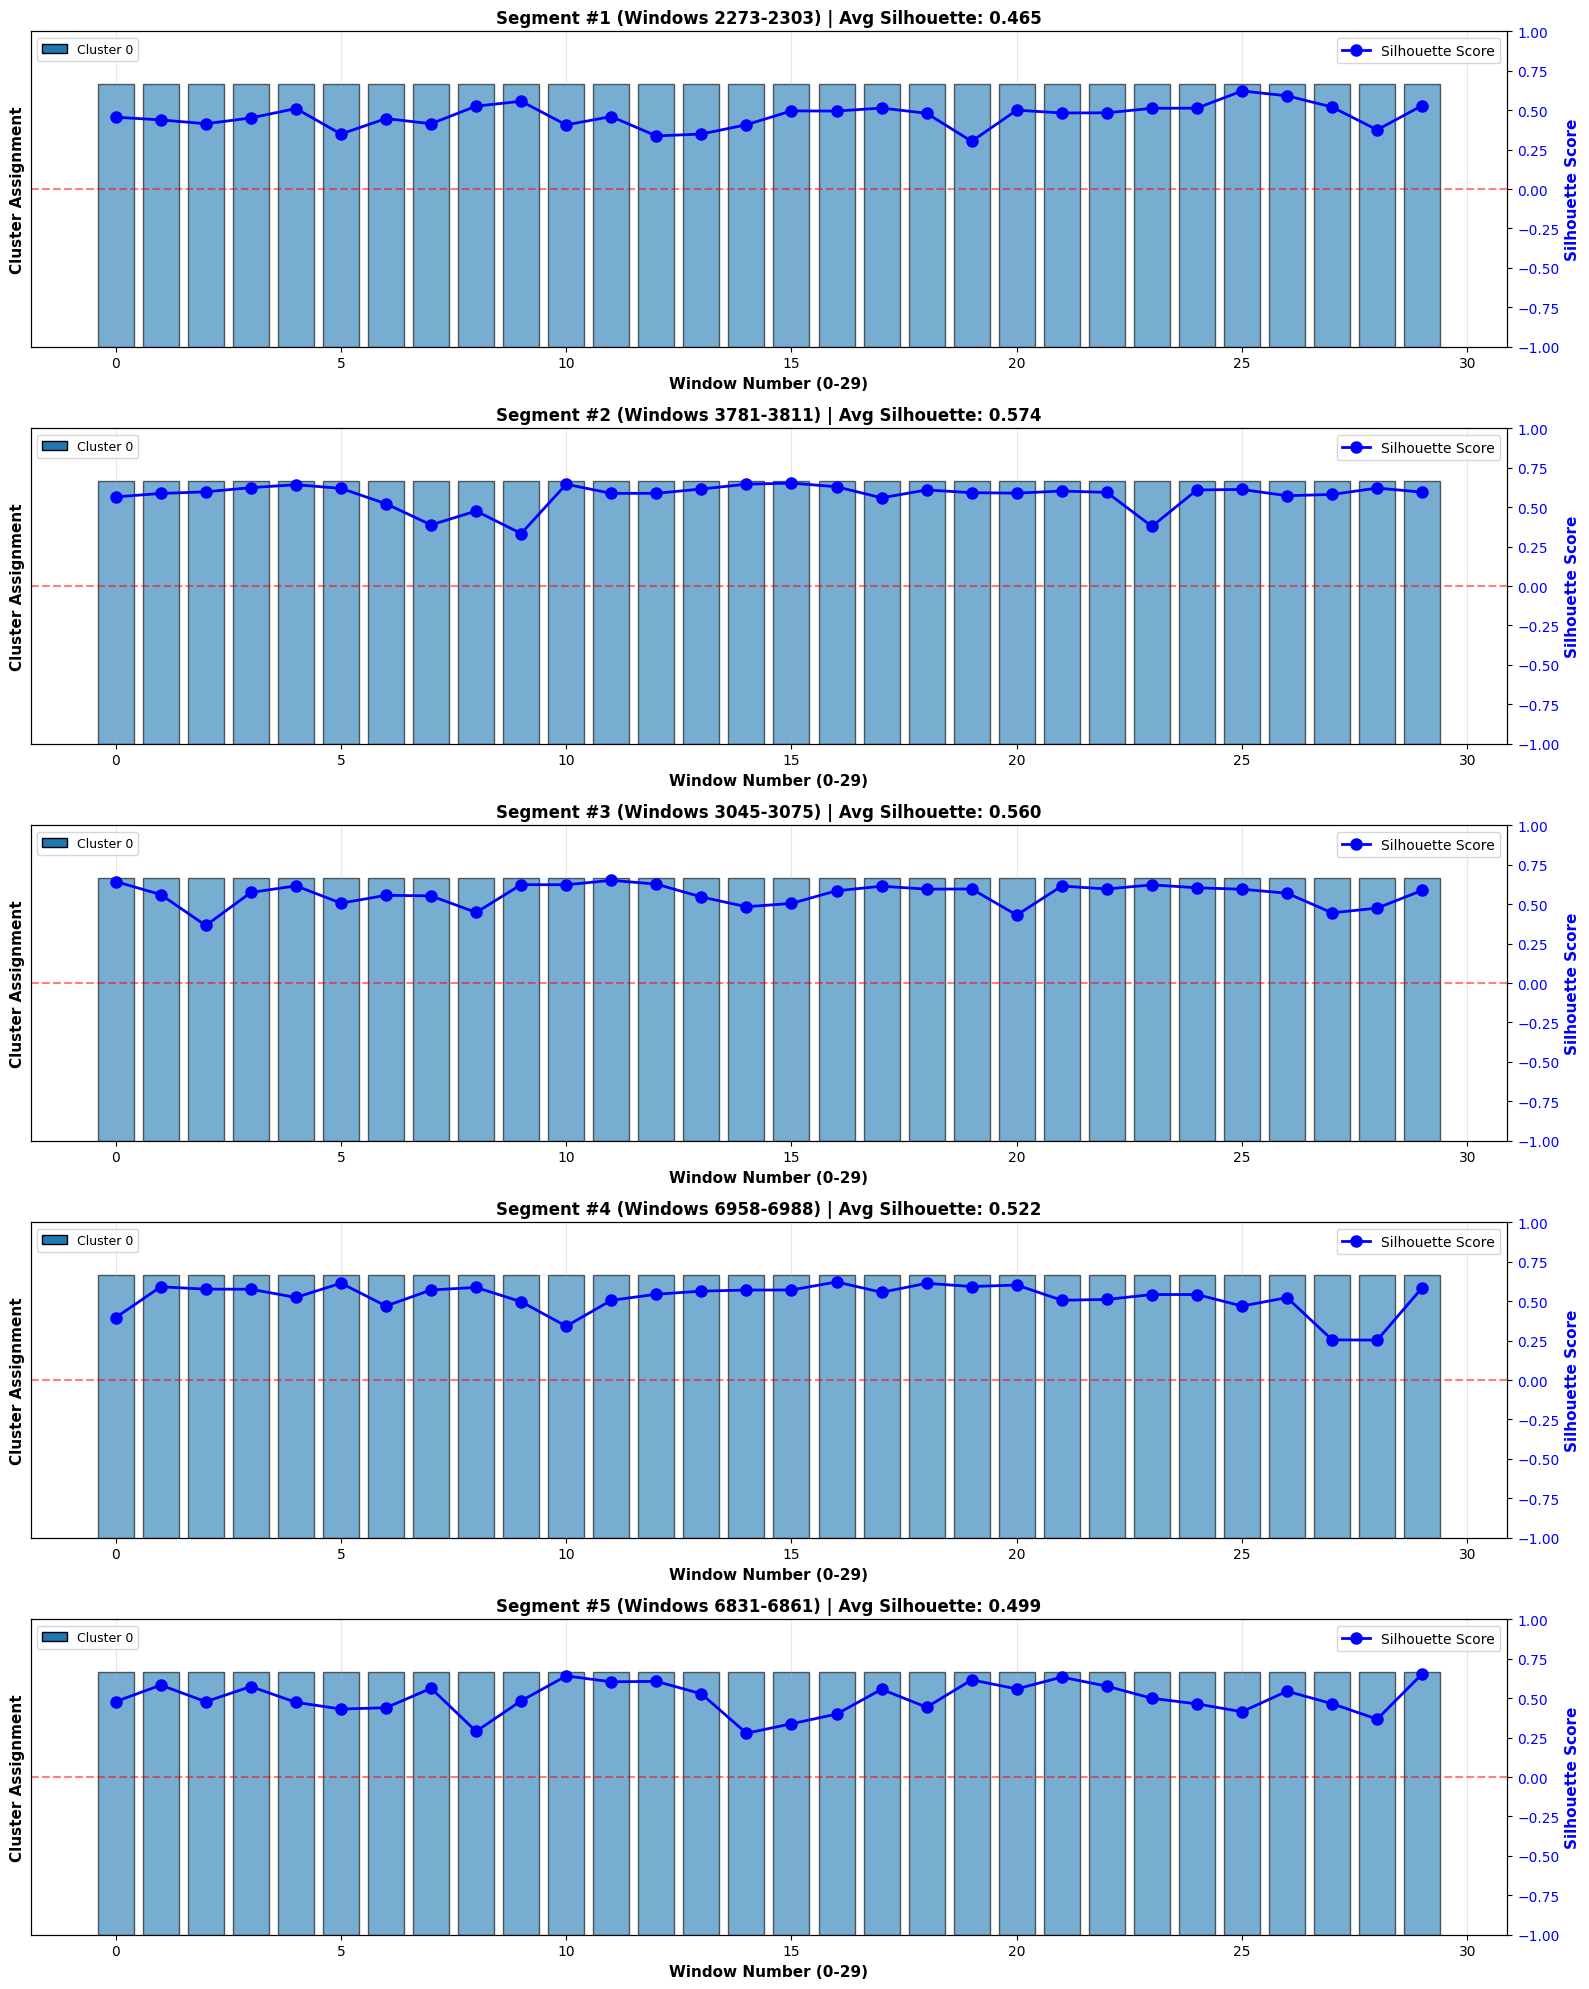


✓ Temporal segment analysis complete!
  Saved as: dbscan_temporal_segments.png

TEMPORAL SEGMENT SUMMARY
Average silhouette across all segments: 0.5242
Silhouette std deviation: 0.0401
Best segment: #2 (silhouette: 0.5745)
Worst segment: #1 (silhouette: 0.4645)


In [31]:
if segments_analysis:
    # Create visualization for each segment
    n_segments = len(segments_analysis)
    fig, axes = plt.subplots(n_segments, 1, figsize=(16, 4*n_segments))

    if n_segments == 1:
        axes = [axes]

    for idx, segment in enumerate(segments_analysis):
        ax = axes[idx]

        windows = range(30)
        labels = segment['labels']
        silhouettes = segment['silhouettes']


        ax.set_title(f'Segment #{idx+1} (Windows {segment["start_idx"]}-{segment["end_idx"]}) | '
                    f'Avg Silhouette: {segment["avg_silhouette"]:.3f}',
                    fontsize=12, fontweight='bold')

        ax.set_ylim(0, 1.2)
        ax.set_yticks([])
        ax_twin.set_ylim(-1, 1)
        ax_twin.legend(loc='upper right')
        ax.grid(True, alpha=0.3, axis='x')

        # Add cluster legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color_dict[label],
                                edgecolor='black',
                                label=f'Cluster {label}' if label != -1 else 'Noise')
                          for label in sorted(set(labels))]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.savefig('dbscan_temporal_segments.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✓ Temporal segment analysis complete!")
    print("  Saved as: dbscan_temporal_segments.png")

    # Summary statistics
    print("\n" + "="*100)
    print("TEMPORAL SEGMENT SUMMARY")
    print("="*100)
    avg_silhouettes = [s['avg_silhouette'] for s in segments_analysis]
    print(f"Average silhouette across all segments: {np.mean(avg_silhouettes):.4f}")
    print(f"Silhouette std deviation: {np.std(avg_silhouettes):.4f}")
    print(f"Best segment: #{np.argmax(avg_silhouettes)+1} (silhouette: {max(avg_silhouettes):.4f})")
    print(f"Worst segment: #{np.argmin(avg_silhouettes)+1} (silhouette: {min(avg_silhouettes):.4f})")
else:
    print("No segments to visualize")



---

## DBSCAN vs K-means Comparison

Let's compare the DBSCAN results with the K-means clustering from the earlier analysis.

### Key Differences:
1. **Cluster count**: K-means requires pre-specification; DBSCAN finds it automatically
2. **Outlier handling**: DBSCAN explicitly identifies outliers; K-means assigns all points
3. **Cluster shape**: K-means assumes spherical; DBSCAN can find arbitrary shapes
4. **Noise sensitivity**: DBSCAN is more robust to outliers

We'll visualize both clusterings side-by-side to understand their differences.




 Creating comparison...


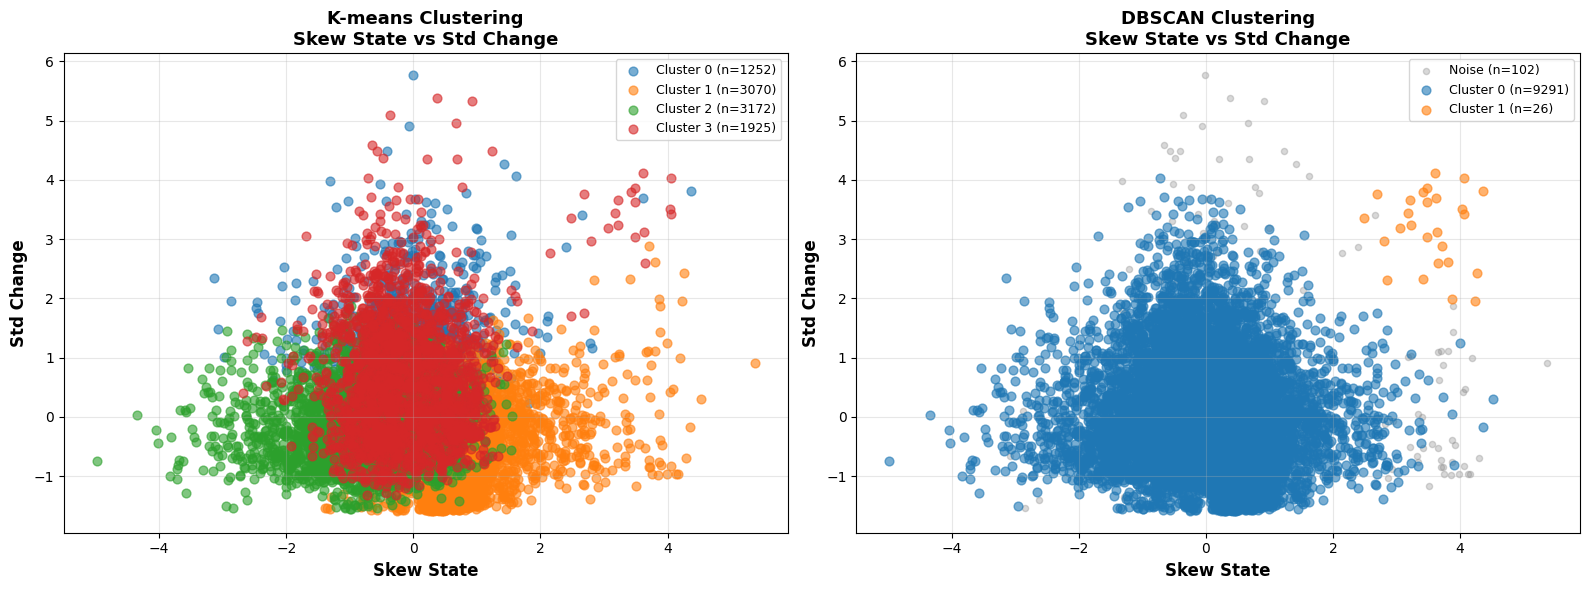


CLUSTERING METHOD COMPARISON

K-means:
  Number of clusters: 4
  All points assigned: Yes
  Outlier detection: No
  Silhouette Score: 0.1972
  Davies-Bouldin Score: 1.5389

DBSCAN:
  Number of clusters: 2
  Noise points: 102 (1.1%)
  Outlier detection: Yes
  Silhouette Score (excl. noise): 0.5150
  Davies-Bouldin Score (excl. noise): 0.5305

CLUSTER AGREEMENT ANALYSIS

For the 9317 non-noise points in DBSCAN:
  Adjusted Rand Index: 0.0008 (1.0 = perfect agreement)
  Normalized Mutual Info: 0.0028 (1.0 = perfect agreement)

✓ Comparison complete!


In [32]:

try:
    kmeans_labels_array = np.array(kmeans_labels)

    print(" Creating comparison...")

    # Create comparison visualizations using best projection
    best_proj = projections_df.iloc[0]
    feat_i, feat_j = best_proj['Feat_Idx']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot K-means
    unique_kmeans = sorted(set(kmeans_labels_array))
    for cluster_id in unique_kmeans:
        mask = kmeans_labels_array == cluster_id
        ax1.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                   alpha=0.6, s=40, label=f'Cluster {cluster_id} (n={mask.sum()})')

    ax1.set_xlabel(best_proj['Feature 1'], fontsize=12, fontweight='bold')
    ax1.set_ylabel(best_proj['Feature 2'], fontsize=12, fontweight='bold')
    ax1.set_title(f'K-means Clustering\n{best_proj["Feature 1"]} vs {best_proj["Feature 2"]}',
                 fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)

    # Plot DBSCAN
    for cluster_id in unique_labels:
        mask = dbscan_labels_array == cluster_id
        if cluster_id == -1:
            ax2.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                       c='grey', alpha=0.3, s=20, label=f'Noise (n={mask.sum()})')
        else:
            ax2.scatter(X_scaled[mask, feat_i], X_scaled[mask, feat_j],
                       c=[color_dict[cluster_id]], alpha=0.6, s=40,
                       label=f'Cluster {cluster_id} (n={mask.sum()})')

    ax2.set_xlabel(best_proj['Feature 1'], fontsize=12, fontweight='bold')
    ax2.set_ylabel(best_proj['Feature 2'], fontsize=12, fontweight='bold')
    ax2.set_title(f'DBSCAN Clustering\n{best_proj["Feature 1"]} vs {best_proj["Feature 2"]}',
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('kmeans_vs_dbscan_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Statistical comparison
    print("\n" + "="*100)
    print("CLUSTERING METHOD COMPARISON")
    print("="*100)

    print(f"\nK-means:")
    print(f"  Number of clusters: {len(unique_kmeans)}")
    print(f"  All points assigned: Yes")
    print(f"  Outlier detection: No")

    if len(unique_kmeans) >= 2:
        kmeans_sil = silhouette_score(X_scaled, kmeans_labels_array)
        kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels_array)
        print(f"  Silhouette Score: {kmeans_sil:.4f}")
        print(f"  Davies-Bouldin Score: {kmeans_db:.4f}")

    print(f"\nDBSCAN:")
    print(f"  Number of clusters: {n_clusters_dbscan}")
    print(f"  Noise points: {n_noise_dbscan} ({noise_pct_dbscan:.1f}%)")
    print(f"  Outlier detection: Yes")

    mask_dbscan = dbscan_labels_array != -1
    if mask_dbscan.sum() > 1 and n_clusters_dbscan >= 2:
        dbscan_sil = silhouette_score(X_scaled[mask_dbscan], dbscan_labels_array[mask_dbscan])
        dbscan_db = davies_bouldin_score(X_scaled[mask_dbscan], dbscan_labels_array[mask_dbscan])
        print(f"  Silhouette Score (excl. noise): {dbscan_sil:.4f}")
        print(f"  Davies-Bouldin Score (excl. noise): {dbscan_db:.4f}")

    # Agreement analysis
    # For points that DBSCAN didn't classify as noise, how do they align with K-means?
    print(f"\n" + "="*100)
    print("CLUSTER AGREEMENT ANALYSIS")
    print("="*100)

    non_noise_indices = dbscan_labels_array != -1

    print(f"\nFor the {non_noise_indices.sum()} non-noise points in DBSCAN:")

    # Create contingency table
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

    ari = adjusted_rand_score(kmeans_labels_array[non_noise_indices],
                             dbscan_labels_array[non_noise_indices])
    nmi = normalized_mutual_info_score(kmeans_labels_array[non_noise_indices],
                                       dbscan_labels_array[non_noise_indices])

    print(f"  Adjusted Rand Index: {ari:.4f} (1.0 = perfect agreement)")
    print(f"  Normalized Mutual Info: {nmi:.4f} (1.0 = perfect agreement)")

    print("\n✓ Comparison complete!")

except NameError:
    print("⚠️ K-means labels not found. Skipping comparison.")
    print("   Make sure you have 'kmeans_labels' variable from earlier K-means analysis.")
    print("   Or update the variable name in this cell to match your K-means labels variable.")